# 06. 데이터 분포 확인

분할별 곡 수와 REAL/FAKE, 장르, 생성기 분포를 확인한다. 특히 생성기별 원곡 수가 달라 전체 Accuracy 하나로는 모델의 약점을 알기 어렵다.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

MANIFEST_PATH = PROJECT_ROOT / "data/metadata/master_manifest_with_split.csv"
EDA_DIR = PROJECT_ROOT / "results/eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("MANIFEST_PATH:", MANIFEST_PATH)
print("EDA_DIR      :", EDA_DIR)

MANIFEST_PATH: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/metadata/master_manifest_with_split.csv
EDA_DIR      : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/eda


## 1. 데이터 로드 및 기본 구조 확인

먼저 전체 행 수, `original_audio` 수, label, split, genre, generator 구조를 확인한다.

In [2]:
df = pd.read_csv(MANIFEST_PATH)

print("===== BASIC STRUCTURE =====")
print("Rows                 :", len(df))
print("Unique original_audio:", df["original_audio"].nunique())
print("Columns              :", df.columns.tolist())

print("\nSplit values:")
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
print(df["split"].value_counts())

print("\nLabel values:")
print(df["label"].value_counts())

print("\nGenre values:")
print(df["genre"].value_counts())

print("\nFAKE generators:")
print(df.loc[df["label"] == "FAKE", "generator"].value_counts())

display(df.head())

===== BASIC STRUCTURE =====
Rows                 : 3458
Unique original_audio: 296
Columns              : ['sample_id', 'original_audio', 'label', 'label_id', 'source', 'genre', 'generator', 'audio_path', 'track_id', 'description', 'path_in_dataset', 'file_exists', 'split']

Split values:
split
train    2392
test      539
val       527
Name: count, dtype: int64

Label values:
label
FAKE    3162
REAL     296
Name: count, dtype: int64

Genre values:
genre
Electronic    1249
Rock          1238
Pop            971
Name: count, dtype: int64

FAKE generators:
generator
suno           300
udio           300
elevenlabs     300
diffrhythm     299
brev           298
acestep        294
musicgen       293
audioldm       292
songgen        292
stableaudio    194
producer       151
mubert         149
Name: count, dtype: int64


,sample_id,original_audio,label,label_id,source,genre,generator,audio_path,track_id,description,path_in_dataset,file_exists,split
0,sample_00000,"10,000 People Chanting, ""I'm an Individual"" - ...",REAL,0,FMA,Electronic,NaN,data/raw/FMA/selected_30s/140/140932.mp3,140932.0,NaN,NaN,True,train
1,sample_00001,1984 - Punk Rock Opera,REAL,0,FMA,Rock,NaN,data/raw/FMA/selected_30s/149/149410.mp3,149410.0,NaN,NaN,True,train
2,sample_00002,2 (Wasn't There) - Isle of Pine,REAL,0,FMA,Rock,NaN,data/raw/FMA/selected_30s/066/066449.mp3,66449.0,NaN,NaN,True,val
3,sample_00003,2Much (Andy Spinelli & Alex Sánchez House Edit...,REAL,0,FMA,Electronic,NaN,data/raw/FMA/selected_30s/114/114244.mp3,114244.0,NaN,NaN,True,test
4,sample_00004,3 am West End - statusq,REAL,0,FMA,Electronic,NaN,data/raw/FMA/selected_30s/112/112378.mp3,112378.0,NaN,NaN,True,test


## 2. Split별 Group 수 확인

분할은 sample이 아니라 `original_audio` group 단위로 수행했기 때문에,
각 split에 몇 개의 source family가 배정되었는지 다시 확인한다.

,original_audio_count,ratio
split,,
test,45,0.152027
train,207,0.699324
val,44,0.148649


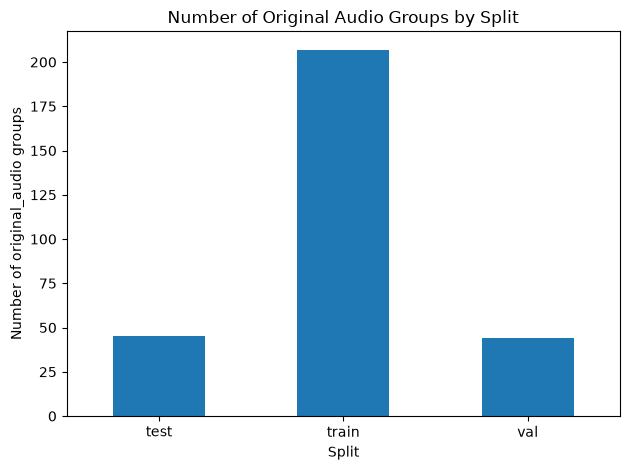

In [3]:
# Split별 Group 수 확인
group_split_summary = (
    df[["original_audio", "genre", "split"]]
    .drop_duplicates("original_audio")
    .groupby("split")
    .agg(original_audio_count=("original_audio", "nunique"))
)

group_split_summary["ratio"] = (
    group_split_summary["original_audio_count"]
    / group_split_summary["original_audio_count"].sum()
)

display(group_split_summary)

ax = group_split_summary["original_audio_count"].plot(
    kind="bar", title="Number of Original Audio Groups by Split", rot=0
)
ax.set_xlabel("Split")
ax.set_ylabel("Number of original_audio groups")
plt.tight_layout()
plt.show()

## 3. Sample-level Split 분포

`original_audio`별 FAKE 생성물 수가 다르기 때문에,
group 비율이 70/15/15에 가깝더라도 sample-level 비율은 정확히 같지 않을 수 있다.

,sample_count,ratio
split,,
train,2392,0.691729
test,539,0.155870
val,527,0.152400


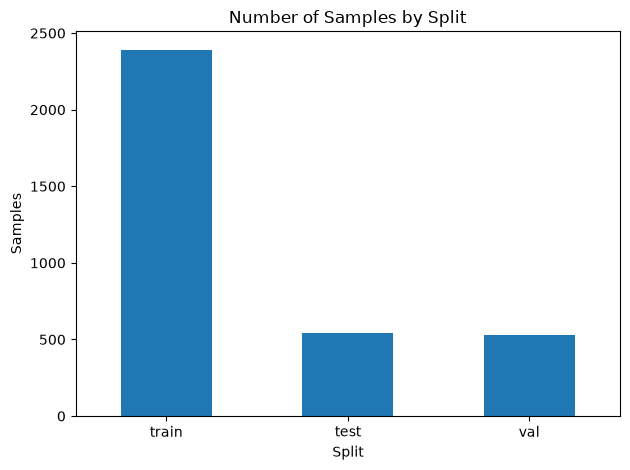

In [4]:
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
sample_split_summary = df["split"].value_counts().rename("sample_count").to_frame()

sample_split_summary["ratio"] = (
    sample_split_summary["sample_count"] / sample_split_summary["sample_count"].sum()
)

display(sample_split_summary)

ax = sample_split_summary["sample_count"].plot(
    kind="bar", title="Number of Samples by Split", rot=0
)
ax.set_xlabel("Split")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.show()

## 4. REAL / FAKE Class Imbalance 확인

현재 데이터는 원곡마다 REAL은 1개지만,
같은 원곡으로부터 여러 AI 생성물이 존재하므로 FAKE 수가 훨씬 많다.

이 비율은 이후 Logistic Regression, SVM, CNN 학습 시
class weight, sampling 또는 loss 설정을 결정하는 데 중요하다.

,count,ratio
label,,
FAKE,3162,0.914401
REAL,296,0.085599


===== LABEL COUNT BY SPLIT =====


label,FAKE,REAL
split,,
test,494,45
train,2185,207
val,483,44


===== LABEL RATIO BY SPLIT =====


label,FAKE,REAL
split,,
test,0.9165,0.0835
train,0.9135,0.0865
val,0.9165,0.0835


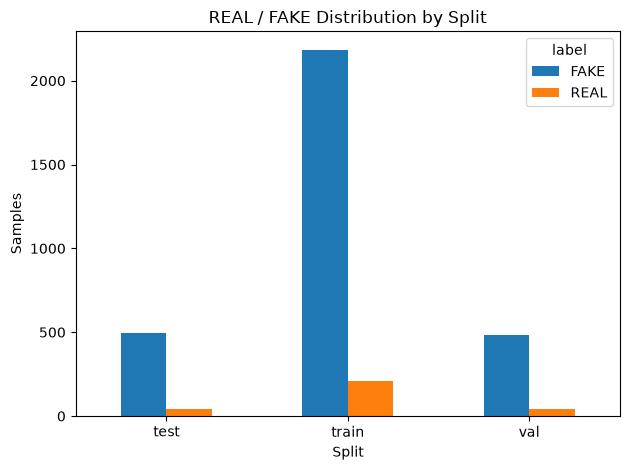

In [5]:
# REAL / FAKE Class Imbalance 확인
label_summary = df["label"].value_counts().rename("count").to_frame()

label_summary["ratio"] = label_summary["count"] / label_summary["count"].sum()

display(label_summary)

label_by_split = pd.crosstab(df["split"], df["label"])

label_ratio_by_split = pd.crosstab(df["split"], df["label"], normalize="index").round(4)

print("===== LABEL COUNT BY SPLIT =====")
display(label_by_split)

print("===== LABEL RATIO BY SPLIT =====")
display(label_ratio_by_split)

ax = label_by_split.plot(kind="bar", title="REAL / FAKE Distribution by Split", rot=0)
ax.set_xlabel("Split")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.show()

## 5. Group-level Genre 분포

장르 stratification은 `original_audio` group 기준으로 수행했다.
따라서 먼저 group-level 장르 분포를 확인한다.

===== GROUP-LEVEL GENRE COUNT =====


genre,Electronic,Pop,Rock
split,,,
test,18,10,17
train,82,47,78
val,18,10,16


===== GROUP-LEVEL GENRE RATIO =====


genre,Electronic,Pop,Rock
split,,,
test,0.4000,0.2222,0.3778
train,0.3961,0.2271,0.3768
val,0.4091,0.2273,0.3636


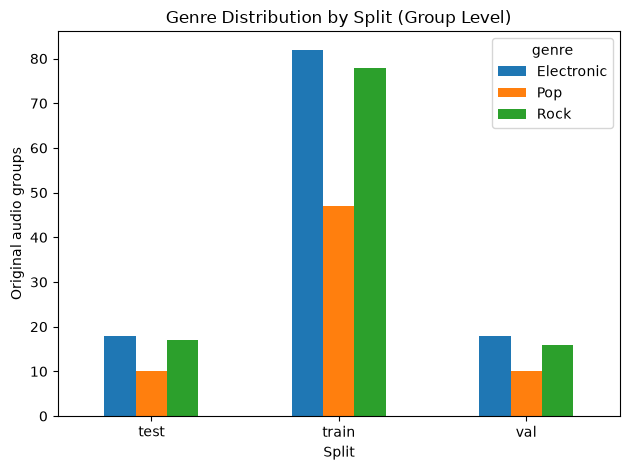

In [6]:
# Group-level Genre 분포
group_level = (
    df[["original_audio", "genre", "split"]].drop_duplicates("original_audio").copy()
)

group_genre_count = pd.crosstab(group_level["split"], group_level["genre"])

group_genre_ratio = pd.crosstab(
    group_level["split"], group_level["genre"], normalize="index"
).round(4)

print("===== GROUP-LEVEL GENRE COUNT =====")
display(group_genre_count)

print("===== GROUP-LEVEL GENRE RATIO =====")
display(group_genre_ratio)

ax = group_genre_count.plot(
    kind="bar", title="Genre Distribution by Split (Group Level)", rot=0
)
ax.set_xlabel("Split")
ax.set_ylabel("Original audio groups")
plt.tight_layout()
plt.show()

## 6. Sample-level Genre 분포

FAKE 생성물 개수가 원곡마다 다르기 때문에
sample-level 장르 분포는 group-level 분포와 조금 달라질 수 있다.

===== SAMPLE-LEVEL GENRE COUNT =====


genre,Electronic,Pop,Rock
split,,,
test,185,141,213
train,894,677,821
val,170,153,204


===== SAMPLE-LEVEL GENRE RATIO =====


genre,Electronic,Pop,Rock
split,,,
test,0.3432,0.2616,0.3952
train,0.3737,0.2830,0.3432
val,0.3226,0.2903,0.3871


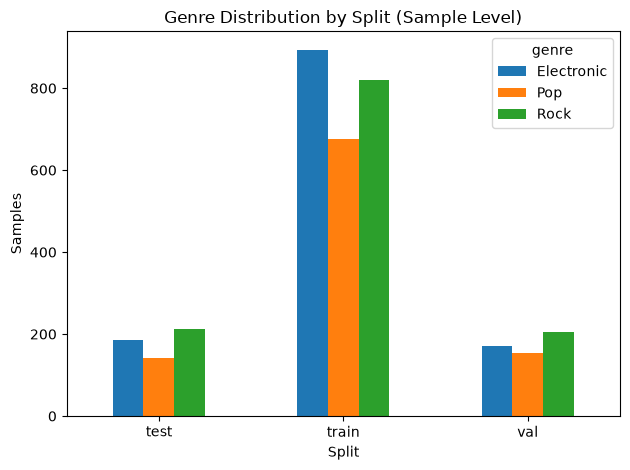

In [7]:
# Sample-level Genre 분포
sample_genre_count = pd.crosstab(df["split"], df["genre"])

sample_genre_ratio = pd.crosstab(df["split"], df["genre"], normalize="index").round(4)

print("===== SAMPLE-LEVEL GENRE COUNT =====")
display(sample_genre_count)

print("===== SAMPLE-LEVEL GENRE RATIO =====")
display(sample_genre_ratio)

ax = sample_genre_count.plot(
    kind="bar", title="Genre Distribution by Split (Sample Level)", rot=0
)
ax.set_xlabel("Split")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.show()

## 7. AI Generator 전체 분포

REAL의 `generator`는 결측값이므로 제외하고 FAKE만 분석한다.

generator별 총 샘플 수가 크게 다르면,
모델이 특정 generator의 특징을 과도하게 학습할 가능성이 있다.

,sample_count,ratio
generator,,
suno,300,0.094877
udio,300,0.094877
elevenlabs,300,0.094877
diffrhythm,299,0.094560
brev,298,0.094244
acestep,294,0.092979
musicgen,293,0.092663
audioldm,292,0.092347
songgen,292,0.092347


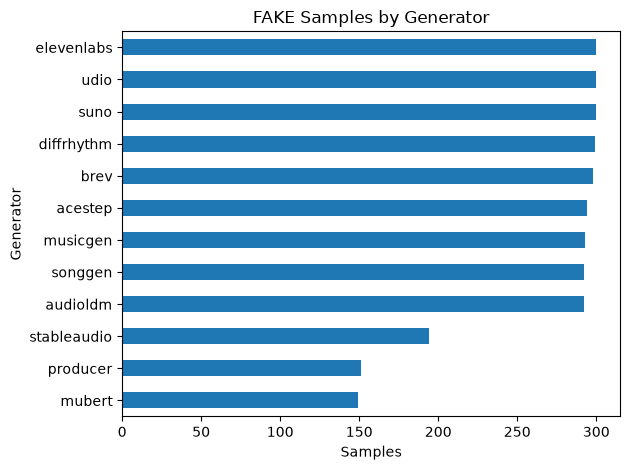

In [8]:
# AI Generator 전체 분포
fake = df[df["label"] == "FAKE"].copy()

generator_summary = fake["generator"].value_counts().rename("sample_count").to_frame()

generator_summary["ratio"] = (
    generator_summary["sample_count"] / generator_summary["sample_count"].sum()
)

display(generator_summary)

ax = (
    generator_summary["sample_count"]
    .sort_values()
    .plot(kind="barh", title="FAKE Samples by Generator")
)
ax.set_xlabel("Samples")
ax.set_ylabel("Generator")
plt.tight_layout()
plt.show()

## 8. Split별 Generator 분포

각 AI generator가 Train / Validation / Test에 어떻게 배정되었는지 확인한다.

이번 기본 split은 generator holdout 실험이 아니라
`original_audio` 기준 in-domain split이므로,
대부분의 generator가 모든 split에 존재할 수 있다.

split,test,train,val
generator,,,
acestep,45,206,43
audioldm,45,203,44
brev,48,204,46
diffrhythm,47,207,45
elevenlabs,48,204,48
mubert,24,100,25
musicgen,45,205,43
producer,25,102,24
songgen,45,205,42


===== GENERATOR SPLIT RATIO =====


split,test,train,val
generator,,,
acestep,0.1531,0.7007,0.1463
audioldm,0.1541,0.6952,0.1507
brev,0.1611,0.6846,0.1544
diffrhythm,0.1572,0.6923,0.1505
elevenlabs,0.1600,0.6800,0.1600
mubert,0.1611,0.6711,0.1678
musicgen,0.1536,0.6997,0.1468
producer,0.1656,0.6755,0.1589
songgen,0.1541,0.7021,0.1438


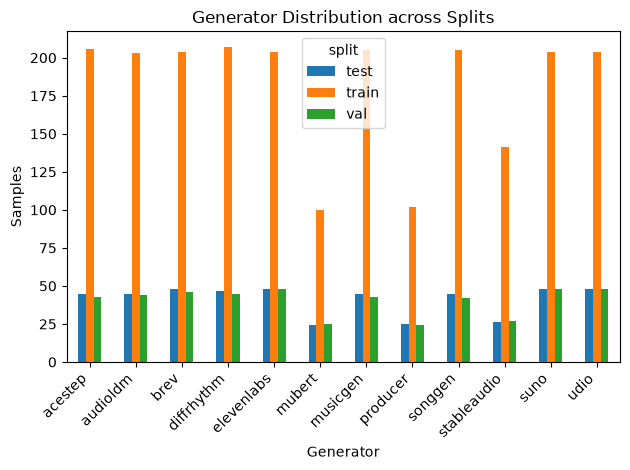

In [9]:
# Split별 Generator 분포
generator_by_split = pd.crosstab(fake["generator"], fake["split"])

display(generator_by_split)

generator_ratio_by_split = pd.crosstab(
    fake["generator"], fake["split"], normalize="index"
).round(4)

print("===== GENERATOR SPLIT RATIO =====")
display(generator_ratio_by_split)

ax = generator_by_split.plot(kind="bar", title="Generator Distribution across Splits")
ax.set_xlabel("Generator")
ax.set_ylabel("Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Generator별 original_audio Coverage

generator마다 전체 296개 원곡을 모두 생성한 것은 아니다.

따라서 단순 샘플 수뿐 아니라
각 generator가 몇 개의 서로 다른 `original_audio`를 포함하는지도 확인한다.

,samples,unique_original_audio,coverage_ratio
generator,,,
acestep,294,293,0.9899
musicgen,293,293,0.9899
audioldm,292,292,0.9865
songgen,292,290,0.9797
diffrhythm,299,289,0.9764
stableaudio,194,185,0.6250
suno,300,151,0.5101
udio,300,151,0.5101
elevenlabs,300,150,0.5068


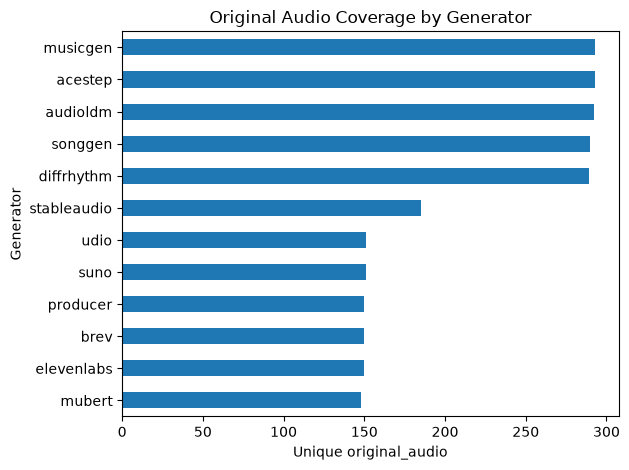

In [10]:
# Generator별 original_audio Coverage
generator_coverage = (
    fake.groupby("generator")
    .agg(
        samples=("sample_id", "size"),
        unique_original_audio=("original_audio", "nunique"),
    )
    .sort_values(["unique_original_audio", "samples"], ascending=False)
)

generator_coverage["coverage_ratio"] = (
    generator_coverage["unique_original_audio"] / 296
).round(4)

display(generator_coverage)

ax = (
    generator_coverage["unique_original_audio"]
    .sort_values()
    .plot(kind="barh", title="Original Audio Coverage by Generator")
)
ax.set_xlabel("Unique original_audio")
ax.set_ylabel("Generator")
plt.tight_layout()
plt.show()

## 10. Generator × Genre 분포

특정 generator가 특정 장르에만 과도하게 집중되어 있는지 확인한다.

generator와 genre가 강하게 연관되어 있다면
모델이 AI artifact가 아니라 장르 특성을 이용할 위험이 있으므로 참고해야 한다.

===== GENERATOR × GENRE COUNT =====


genre,Electronic,Pop,Rock
generator,,,
acestep,116,67,111
audioldm,116,65,111
brev,99,100,99
diffrhythm,117,75,107
elevenlabs,100,100,100
mubert,50,49,50
musicgen,118,67,108
producer,50,51,50
songgen,118,67,107


===== GENERATOR × GENRE RATIO =====


genre,Electronic,Pop,Rock
generator,,,
acestep,0.3946,0.2279,0.3776
audioldm,0.3973,0.2226,0.3801
brev,0.3322,0.3356,0.3322
diffrhythm,0.3913,0.2508,0.3579
elevenlabs,0.3333,0.3333,0.3333
mubert,0.3356,0.3289,0.3356
musicgen,0.4027,0.2287,0.3686
producer,0.3311,0.3377,0.3311
songgen,0.4041,0.2295,0.3664


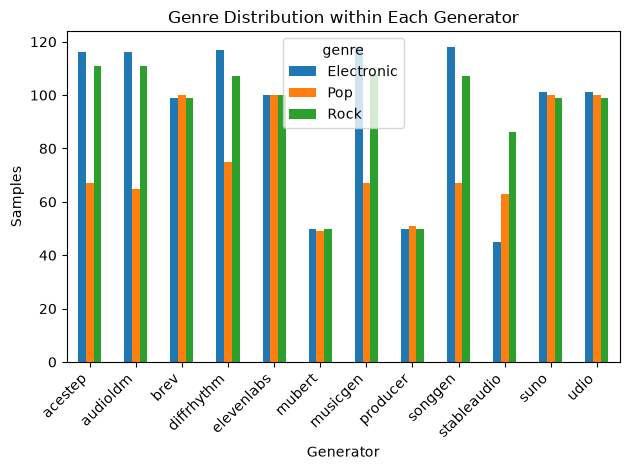

In [11]:
# Generator × Genre 분포
generator_genre = pd.crosstab(fake["generator"], fake["genre"])

generator_genre_ratio = pd.crosstab(
    fake["generator"], fake["genre"], normalize="index"
).round(4)

print("===== GENERATOR × GENRE COUNT =====")
display(generator_genre)

print("===== GENERATOR × GENRE RATIO =====")
display(generator_genre_ratio)

ax = generator_genre.plot(kind="bar", title="Genre Distribution within Each Generator")
ax.set_xlabel("Generator")
ax.set_ylabel("Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. original_audio별 Sample 수 분포

원곡마다 연결된 AI 생성물 수가 다르므로,
특정 source family가 데이터에서 과도하게 큰 비중을 차지하는지 확인한다.

===== TOTAL SAMPLES PER ORIGINAL_AUDIO =====


count    296.000000
mean      11.682432
std        5.287064
min        2.000000
25%        6.000000
50%       14.500000
75%       17.000000
max       20.000000
Name: total_samples, dtype: float64

===== FAKE SAMPLES PER ORIGINAL_AUDIO =====


count    296.000000
mean      10.682432
std        5.287064
min        1.000000
25%        5.000000
50%       13.500000
75%       16.000000
max       19.000000
Name: fake_samples, dtype: float64


Largest source families:


,original_audio,split,genre,total_samples,fake_samples
288,purity & danger - Katapulto,train,Pop,20,19
151,New Life (take 1) - Bird Names,val,Pop,19,18
41,Colossal Stillness - Scott Holmes,train,Rock,18,17
149,Nature Is Over / Defined - Bird Names,train,Pop,18,17
146,Music For an Underground Circu - Ergo Phizmiz,test,Pop,18,17
239,The Reality Machine - Monroeville Music Center,train,Pop,18,17
211,Stockholm Syndrome / People Should Be More Awa...,val,Pop,18,17
198,She Works / Tepid Waters - Bird Names,test,Pop,18,17
252,Troubles I've seen - Malaventura,test,Pop,18,17
87,"Head of Ancante, Talking Tree - Ak'chamel, The...",test,Rock,17,16


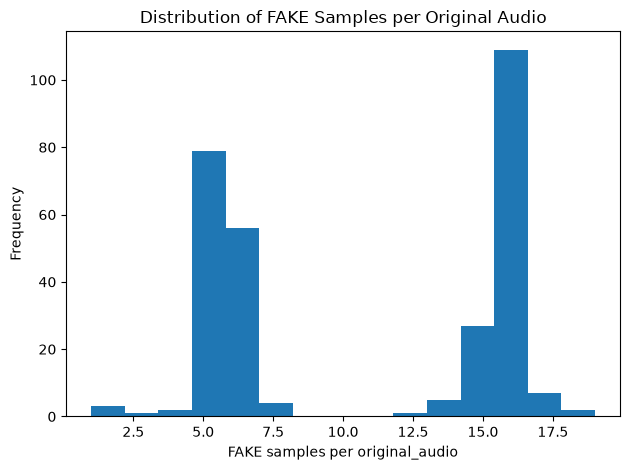

In [12]:
# original_audio별 Sample 수 분포
group_sample_count = (
    df.groupby(["original_audio", "split", "genre"])
    .agg(
        total_samples=("sample_id", "size"),
        fake_samples=("label", lambda x: (x == "FAKE").sum()),
    )
    .reset_index()
)

print("===== TOTAL SAMPLES PER ORIGINAL_AUDIO =====")
display(group_sample_count["total_samples"].describe())

print("===== FAKE SAMPLES PER ORIGINAL_AUDIO =====")
display(group_sample_count["fake_samples"].describe())

print("\nLargest source families:")
display(group_sample_count.sort_values("total_samples", ascending=False).head(20))

ax = group_sample_count["fake_samples"].plot(
    kind="hist", bins=15, title="Distribution of FAKE Samples per Original Audio"
)
ax.set_xlabel("FAKE samples per original_audio")
plt.tight_layout()
plt.show()

## 12. Split별 source-family 크기 비교

Train / Validation / Test 중 특정 split에 큰 source family가 과도하게 몰렸는지 확인한다.

In [13]:
# Split별 source-family 크기 비교
family_size_by_split = (
    group_sample_count.groupby("split")["fake_samples"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)

display(family_size_by_split)

,count,mean,std,min,median,max
split,,,,,,
test,45,10.98,5.37,5,15.0,17
train,207,10.56,5.30,1,8.0,19
val,44,10.98,5.26,5,14.0,18


## 13. EDA 요약 테이블 저장

추후 보고서와 발표 자료에서 재사용할 수 있도록
핵심 요약표를 `results/eda/`에 CSV로 저장한다.

In [14]:
group_split_summary.to_csv(EDA_DIR / "group_split_summary.csv", encoding="utf-8-sig")

sample_split_summary.to_csv(EDA_DIR / "sample_split_summary.csv", encoding="utf-8-sig")

label_by_split.to_csv(EDA_DIR / "label_by_split.csv", encoding="utf-8-sig")

group_genre_count.to_csv(EDA_DIR / "group_genre_by_split.csv", encoding="utf-8-sig")

sample_genre_count.to_csv(EDA_DIR / "sample_genre_by_split.csv", encoding="utf-8-sig")

generator_summary.to_csv(EDA_DIR / "generator_summary.csv", encoding="utf-8-sig")

generator_by_split.to_csv(EDA_DIR / "generator_by_split.csv", encoding="utf-8-sig")

generator_coverage.to_csv(EDA_DIR / "generator_coverage.csv", encoding="utf-8-sig")

generator_genre.to_csv(EDA_DIR / "generator_genre.csv", encoding="utf-8-sig")

group_sample_count.to_csv(
    EDA_DIR / "original_audio_sample_counts.csv", index=False, encoding="utf-8-sig"
)

print("Saved EDA tables to:", EDA_DIR)

Saved EDA tables to: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/eda


## 14. 핵심 EDA QC 요약

모델링 전 반드시 확인할 최소 조건을 요약한다.

In [15]:
eda_qc = pd.DataFrame(
    {
        "check": [
            "total_samples",
            "original_audio_groups",
            "real_samples",
            "fake_samples",
            "ai_generators",
            "train_groups",
            "val_groups",
            "test_groups",
            "missing_split",
            "missing_audio_path",
        ],
        "value": [
            len(df),
            df["original_audio"].nunique(),
            int((df["label"] == "REAL").sum()),
            int((df["label"] == "FAKE").sum()),
            fake["generator"].nunique(),
            group_level.loc[
                # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
                group_level["split"] == "train", "original_audio"
            ].nunique(),
            group_level.loc[group_level["split"] == "val", "original_audio"].nunique(),
            group_level.loc[group_level["split"] == "test", "original_audio"].nunique(),
            int(df["split"].isna().sum()),
            int(df["audio_path"].isna().sum()),
        ],
    }
)

display(eda_qc)

eda_qc_pass = (
    len(df) == 3458
    and df["original_audio"].nunique() == 296
    and int((df["label"] == "REAL").sum()) == 296
    and int((df["label"] == "FAKE").sum()) == 3162
    and fake["generator"].nunique() == 12
    and int(df["split"].isna().sum()) == 0
    and int(df["audio_path"].isna().sum()) == 0
)

print("===== FINAL RESULT =====")
print("EDA Core QC PASS:", eda_qc_pass)

,check,value
0,total_samples,3458
1,original_audio_groups,296
2,real_samples,296
3,fake_samples,3162
4,ai_generators,12
5,train_groups,207
6,val_groups,44
7,test_groups,45
8,missing_split,0
9,missing_audio_path,0


===== FINAL RESULT =====
EDA Core QC PASS: True


## 이어지는 기록

확인한 Track을 07번에서 공통 10초 구간으로 나눈다.

## 분포 확인

- 전체 3,458개 sample, 296개 source group의 label·genre·generator·split 분포를 점검했다.
- Split별 sample 수는 Train 2,392, Validation 527, Test 539다.
- Split별 장르 분포와 generator coverage, source-family 크기를 결과 표로 저장했다.
- EDA 표는 `results/eda/`에 저장되어 후속 실험의 데이터 구성 근거로 사용된다.